In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



In [6]:
df = pd.read_csv("messy_classification_1500.csv")

df

,Customer_ID,Age,Monthly_Income_k,Tenure_Years,Monthly_Usage_Hours,Complaints,Satisfaction_Score,Contract_Type,Region,Support_Calls,Churn
0,10001,39.4,33.0,10.36,NaN,1,6.5,Monthly,East,2,0
1,10002,24.6,31.9,15.12,14.6,1,4.2,Yearly,south,2,0
2,10003,44.3,93.3,NaN,19.3,7,6.7,Monthly,East,3,1
3,10004,46.3,54.0,0.65,14.5,3,7.1,monthly,south,1,1
4,10005,18.0,40.1,3.80,3.1,1,7.0,monthly,south,3,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,11496,23.9,29.5,3.44,17.1,1,5.6,Two-Year,South,3,1
1496,11497,39.6,23.1,3.02,18.8,1,6.5,monthly,South,0,1
1497,11498,23.3,162.2,2.54,1.0,2,5.5,Monthly,south,0,0
1498,11499,43.8,70.6,4.00,15.3,0,6.1,two year,North,3,0


In [3]:
print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          1500 non-null   int64  
 1   Age                  1455 non-null   float64
 2   Monthly_Income_k     1456 non-null   float64
 3   Tenure_Years         1455 non-null   float64
 4   Monthly_Usage_Hours  1455 non-null   float64
 5   Complaints           1500 non-null   int64  
 6   Satisfaction_Score   1455 non-null   float64
 7   Contract_Type        1455 non-null   object 
 8   Region               1455 non-null   object 
 9   Support_Calls        1500 non-null   int64  
 10  Churn                1500 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 129.0+ KB
None

Summary Statistics:
        Customer_ID          Age  Monthly_Income_k  Tenure_Years  \
count   1500.000000  1455.000000       1456.000000   1455.00000

In [4]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1500, 11)


In [5]:
num_cols = [
    "Age",
    "Monthly_Income_k",
    "Tenure_Years",
    "Monthly_Usage_Hours",
    "Complaints",
    "Satisfaction_Score",
    "Support_Calls"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[num_cols].dtypes)

Age                    float64
Monthly_Income_k       float64
Tenure_Years           float64
Monthly_Usage_Hours    float64
Complaints               int64
Satisfaction_Score     float64
Support_Calls            int64
dtype: object


In [28]:
# Clean categorical columns

df["Contract_Type"] = (
    df["Contract_Type"]
    .astype(object)
    .str.strip()
    .str.lower()
)

df["Contract_Type"] = df["Contract_Type"].replace({
    "monthly": "Monthly",
    "yearly": "Yearly",
    "two year": "Two-Year",
    "two-year": "Two-Year"
})

df["Region"] = (
    df["Region"]
    .astype(object)
    .str.strip()
    .str.lower()
)

df["Region"] = df["Region"].replace({
    "east": "East",
    "west": "West",
    "north": "North",
    "south": "South"
})

# Convert pandas NA to regular NaN
df["Contract_Type"] = df["Contract_Type"].replace({pd.NA: np.nan})
df["Region"] = df["Region"].replace({pd.NA: np.nan})

print(df[["Contract_Type", "Region"]].dtypes)
print(df[["Contract_Type", "Region"]].isnull().sum())

Contract_Type    object
Region           object
dtype: object
Contract_Type    45
Region           45
dtype: int64


In [29]:
for col in num_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower_bound, upper_bound)

print("Outliers handled using IQR clipping.")

Outliers handled using IQR clipping.


In [30]:
X = df.drop(columns=["Customer_ID", "Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 9)
y shape: (1500,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1200, 9)
Testing set: (300, 9)


In [32]:
cat_cols = [
    "Contract_Type",
    "Region"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [33]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)
logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("\nLogistic Regression")
print(classification_report(y_test, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       188
           1       0.63      0.47      0.54       112

    accuracy                           0.70       300
   macro avg       0.68      0.65      0.66       300
weighted avg       0.69      0.70      0.69       300



In [23]:
print(df[cat_cols].dtypes)
print(df[cat_cols].isnull().sum())
print(df[cat_cols].head())

Contract_Type    string[python]
Region           string[python]
dtype: object
Contract_Type    45
Region           45
dtype: int64
  Contract_Type Region
0       Monthly   East
1        Yearly  South
2       Monthly   East
3       Monthly  South
4       Monthly  South


In [34]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("\nDecision Tree")
print(classification_report(y_test, y_pred_dt))


Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.77      0.75       188
           1       0.57      0.53      0.55       112

    accuracy                           0.68       300
   macro avg       0.65      0.65      0.65       300
weighted avg       0.67      0.68      0.67       300



In [35]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.71      0.83      0.76       188
           1       0.60      0.43      0.50       112

    accuracy                           0.68       300
   macro avg       0.65      0.63      0.63       300
weighted avg       0.67      0.68      0.67       300



In [36]:
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

results = []

for name, y_pred in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.700000   0.630952  0.473214  0.540816
1        Decision Tree  0.676667   0.572816  0.526786  0.548837
2        Random Forest  0.680000   0.600000  0.428571  0.500000


In [37]:
for name, y_pred in models.items():

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)


Logistic Regression
[[157  31]
 [ 59  53]]

Decision Tree
[[144  44]
 [ 53  59]]

Random Forest
[[156  32]
 [ 64  48]]


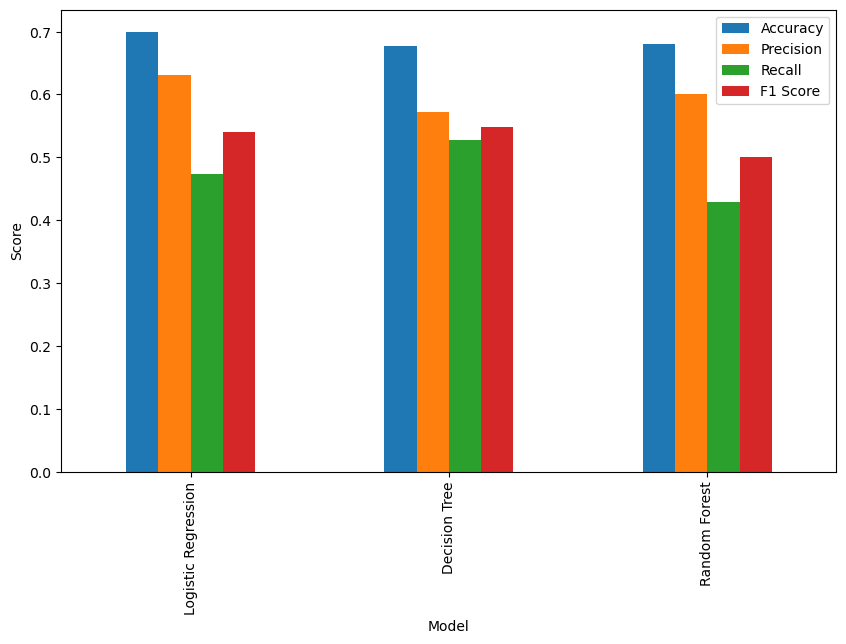

In [45]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.show()